# Optimización controlada de un modelo de ensamble
## 1. Dataset, problema y evaluación
Se utiliza **Breast Cancer Wisconsin (Diagnostic)**, disponible mediante `load_breast_cancer` de Scikit-learn y procedente de UCI. Cada observación representa una muestra de una masa mamaria, descrita mediante mediciones de núcleos celulares obtenidas de una imagen digitalizada de aspiración con aguja fina. Contiene 569 observaciones y 30 características numéricas: medidas medias, errores estándar y valores extremos de propiedades como radio, textura y área.

**Problema:** clasificación binaria del diagnóstico. La variable objetivo será `maligno`: **1 = maligno; 0 = benigno**. Se invierte expresamente la codificación original de Scikit-learn.

**Métrica principal: F1 de la clase maligna.** Combina precision y recall y evita que la clase mayoritaria domine la evaluación como puede ocurrir con accuracy. Se complementa con **recall**, para identificar casos malignos omitidos, **precision** y **ROC-AUC**. F1 no asigna un costo clínico específico a cada error; este es un ejercicio académico.

**Protocolo fijado antes de evaluar:** 80/20 estratificado, semilla 42, Random Forest de 100 árboles, selección de 15 variables por ANOVA y búsqueda aleatoria de 12 configuraciones con 5 particiones. Las decisiones se toman en entrenamiento. La prueba se abre una sola vez al final para comparar las tres alternativas; las tablas solicitadas se presentan allí juntas.

**Ejecución:** en Colab, subir este archivo y seleccionar *Entorno de ejecución → Ejecutar todas*. No se requiere descargar datos, GPU ni instalar dependencias adicionales en Colab.

Fuentes: [dataset en Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html), [dataset original UCI](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).

In [1]:
import sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, ConfusionMatrixDisplay
SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 15)
print('Python:', sys.version.split()[0], '| Scikit-learn:', sklearn.__version__)


Python: 3.13.15 | Scikit-learn: 1.6.1


## 2. Carga y preparación mínima
Se inspeccionan tipos, faltantes, duplicados y balance de clases. Los duplicados exactos, si existen, se eliminan antes de separar para evitar copias a ambos lados de la partición. No se eliminan observaciones solo por tener valores extremos. Todas las variables son numéricas; no hay categorías que codificar.

Se usa un pipeline con imputación por mediana, calculada exclusivamente en entrenamiento. Aunque las escalas difieren, **Random Forest no necesita estandarización**, porque divide cada variable por umbrales y no calcula distancias. El estadístico F de ANOVA tampoco depende de las unidades de cada variable.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.data.copy()
df['maligno'] = (data.target == 0).astype(int)
print('Dimensiones iniciales:', df.shape)
display(pd.DataFrame({'tipo': df.dtypes.astype(str), 'faltantes': df.isna().sum()}))
print('Duplicados exactos:', df.duplicated().sum())
df = df.drop_duplicates().copy()
X = df.drop(columns='maligno')
y = df['maligno']
display(pd.DataFrame({'registros': y.value_counts().sort_index(),
                      'porcentaje': y.value_counts(normalize=True).sort_index()*100}))
print('0 = benigno | 1 = maligno')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
print('Entrenamiento:', X_train.shape, '| Prueba reservada:', X_test.shape)
print('Proporción maligna en entrenamiento:', round(y_train.mean(), 4))
assert set(X_train.index).isdisjoint(X_test.index)


Dimensiones iniciales: (569, 31)


,tipo,faltantes
mean radius,float64,0
mean texture,float64,0
mean perimeter,float64,0
mean area,float64,0
mean smoothness,float64,0
mean compactness,float64,0
mean concavity,float64,0
mean concave points,float64,0
mean symmetry,float64,0
mean fractal dimension,float64,0


Duplicados exactos: 0


,registros,porcentaje
maligno,,
0,357,62.741652
1,212,37.258348


0 = benigno | 1 = maligno
Entrenamiento: (455, 30) | Prueba reservada: (114, 30)
Proporción maligna en entrenamiento: 0.3736


## 3. Modelo base y validación en entrenamiento
Configuración inicial: 100 árboles, profundidad sin límite, `min_samples_split=2`, `min_samples_leaf=1` y `max_features='sqrt'`. Se fija la semilla y se usa un solo proceso para que los tiempos sean comparables y no exista paralelismo anidado.

Se emplea **StratifiedKFold de 5 particiones**, mezcladas con semilla 42. Cada registro de entrenamiento sirve una vez para validar y cuatro para entrenar. Promediar los cinco resultados reduce la dependencia de una sola división; la desviación estándar muestra variación entre particiones, no un intervalo de confianza. Los mismos índices se reutilizan para todos los modelos.

In [3]:
folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X_train, y_train))
scoring = {'f1': 'f1', 'recall': 'recall', 'auc': 'roc_auc'}
def make_model(reduced=False):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if reduced:
        steps.append(('selector', SelectKBest(score_func=f_classif, k=15)))
    steps.append(('rf', RandomForestClassifier(n_estimators=100, max_depth=None,
                  min_samples_split=2, min_samples_leaf=1, max_features='sqrt',
                  random_state=SEED, n_jobs=1)))
    return Pipeline(steps)
base = make_model()
base_cv = cross_validate(base, X_train, y_train, cv=folds, scoring=scoring,
                         return_train_score=True, n_jobs=1, error_score='raise')
def cv_row(name, res):
    return {'Modelo': name, 'F1 CV': res['test_f1'].mean(),
            'DE F1 CV': res['test_f1'].std(ddof=1),
            'F1 entrenamiento CV': res['train_f1'].mean(),
            'Recall CV': res['test_recall'].mean(), 'ROC-AUC CV': res['test_auc'].mean()}
display(pd.DataFrame([cv_row('Base', base_cv)]).round(4))


,Modelo,F1 CV,DE F1 CV,F1 entrenamiento CV,Recall CV,ROC-AUC CV
0,Base,0.9519,0.0232,1.0,0.9412,0.9889


## 4. Redundancia y selección de características
Se revisan correlaciones absolutas mayores a 0.90 **solo en entrenamiento**, como diagnóstico de redundancia. Se aplica **SelectKBest con `f_classif`**: ordena las variables por la relación entre variabilidad entre clases y variabilidad dentro de las clases. Conserva las 15 de mayor puntuación; este número se fija a priori para estudiar una reducción del 50%, sin consultar la prueba.

La selección conserva nombres y unidades originales; no crea componentes. Es un criterio univariado: puede descartar interacciones útiles y conservar variables correlacionadas entre sí. Una puntuación baja no demuestra que una variable sea inútil. Al estar dentro del pipeline, imputación y selección se vuelven a ajustar dentro de cada fold, sin utilizar su parte de validación.

Referencia: [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html).

In [4]:
corr = X_train.corr().abs()
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print('Pares con correlación absoluta > 0.90:', int((pairs > 0.90).sum()))
display(pairs[pairs > 0.90].rename('Correlación absoluta').head(12).to_frame())
print('Variables constantes en entrenamiento:', list(X_train.columns[X_train.nunique() <= 1]))
reduced = make_model(reduced=True)
reduced_cv = cross_validate(reduced, X_train, y_train, cv=folds, scoring=scoring,
                            return_train_score=True, n_jobs=1, error_score='raise')
display(pd.DataFrame([cv_row('Base', base_cv), cv_row('Reducido', reduced_cv)]).round(4))


Pares con correlación absoluta > 0.90: 21


Correlación absoluta
mean radius     mean perimeter               0.997815
worst radius    worst perimeter              0.993719
mean radius     mean area                    0.986740
mean perimeter  mean area                    0.985960
worst radius    worst area                   0.983107
worst perimeter worst area                   0.976665
radius error    perimeter error              0.974705
mean perimeter  worst perimeter              0.970006
                worst radius                 0.969332
mean radius     worst radius                 0.969256
                worst perimeter              0.964439
mean area       worst radius                 0.960725

Variables constantes en entrenamiento: []


,Modelo,F1 CV,DE F1 CV,F1 entrenamiento CV,Recall CV,ROC-AUC CV
0,Base,0.9519,0.0232,1.0,0.9412,0.9889
1,Reducido,0.9311,0.0316,1.0,0.9176,0.9861


## 5. Ajuste sistemático de hiperparámetros
Se utiliza **RandomizedSearchCV**, 12 combinaciones muestreadas sin reemplazo de un espacio de 144 combinaciones, con 5 folds: **60 ajustes**. Se maximiza F1 maligno. Se mantiene `k=15` para aislar el efecto de ajustar el bosque respecto del modelo reducido. No se garantiza encontrar el óptimo global.

Más árboles suelen aumentar tiempo y memoria; limitar profundidad o aumentar el mínimo de muestras por división regulariza los árboles; `max_features` controla cuántas variables compiten en cada división. El conjunto de prueba no participa en esta búsqueda: elegir parámetros con él contaminaría la estimación final de generalización.

Referencia: [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

In [5]:
space = {'rf__n_estimators': [100, 200, 300],
         'rf__max_depth': [None, 4, 8, 12],
         'rf__min_samples_split': [2, 5, 10],
         'rf__max_features': ['sqrt', 0.5, 0.8, 1.0]}
search = RandomizedSearchCV(reduced, param_distributions=space, n_iter=12,
                           scoring=scoring, refit='f1', cv=folds, random_state=SEED,
                           n_jobs=1, return_train_score=True, error_score='raise')
t0 = time.perf_counter()
search.fit(X_train, y_train)
search_seconds = time.perf_counter() - t0
print(f'Tiempo de búsqueda (incluye refit): {search_seconds:.2f} s')
print(f'Mejor F1 medio CV: {search.best_score_:.4f}')
display(pd.DataFrame([{'Hiperparámetro': p.replace('rf__', ''),
                       'Valores explorados (espacio)': str(v),
                       'Mejor valor': str(search.best_params_[p])} for p, v in space.items()]))
cv_results = pd.DataFrame(search.cv_results_)
print('Configuraciones efectivamente evaluadas, ordenadas por F1:')
display(cv_results[['params', 'mean_test_f1', 'std_test_f1', 'mean_train_f1',
                    'mean_fit_time', 'rank_test_f1']].sort_values('rank_test_f1').reset_index(drop=True))
b = search.best_index_
opt_scores = np.array([cv_results.loc[b, f'split{i}_test_f1'] for i in range(5)])
opt_cv_row = {'Modelo': 'Optimizado', 'F1 CV': opt_scores.mean(),
              'DE F1 CV': opt_scores.std(ddof=1),
              'F1 entrenamiento CV': cv_results.loc[b, 'mean_train_f1'],
              'Recall CV': cv_results.loc[b, 'mean_test_recall'],
              'ROC-AUC CV': cv_results.loc[b, 'mean_test_auc']}
cv_table = pd.DataFrame([cv_row('Base', base_cv), cv_row('Reducido', reduced_cv), opt_cv_row]).set_index('Modelo')
display(cv_table.round(4))
# Regla fijada antes de abrir la prueba: tolerancia práctica de 0.01 F1.
# Dentro de esa tolerancia respecto al mejor promedio CV, preferir menos variables y árboles.
cv_best = cv_table['F1 CV'].max()
candidates = {'Base': (30, 100), 'Reducido': (15, 100),
              'Optimizado': (15, search.best_params_['rf__n_estimators'])}
eligible = [name for name in candidates if cv_table.loc[name, 'F1 CV'] >= cv_best - 0.01]
recommended = min(eligible, key=lambda name: (*candidates[name], -cv_table.loc[name, 'F1 CV']))
print('Recomendación provisional basada exclusivamente en CV:', recommended)
print('La tolerancia de 0.01 es un criterio práctico, no una prueba de equivalencia estadística.')


Tiempo de búsqueda (incluye refit): 52.21 s
Mejor F1 medio CV: 0.9257


,Hiperparámetro,Valores explorados (espacio),Mejor valor
0,n_estimators,"[100, 200, 300]",100
1,max_depth,"[None, 4, 8, 12]",8
2,min_samples_split,"[2, 5, 10]",10
3,max_features,"['sqrt', 0.5, 0.8, 1.0]",sqrt


Configuraciones efectivamente evaluadas, ordenadas por F1:


,params,mean_test_f1,std_test_f1,mean_train_f1,mean_fit_time,rank_test_f1
0,"{'rf__n_estimators': 100, 'rf__min_samples_spl...",0.925673,0.021710,0.975541,0.205144,1
1,"{'rf__n_estimators': 100, 'rf__min_samples_spl...",0.922675,0.031211,0.995566,0.260594,2
2,"{'rf__n_estimators': 200, 'rf__min_samples_spl...",0.922543,0.036435,1.000000,0.730212,3
3,"{'rf__n_estimators': 100, 'rf__min_samples_spl...",0.922320,0.037891,1.000000,0.938117,4
4,"{'rf__n_estimators': 100, 'rf__min_samples_spl...",0.920062,0.031077,0.968816,0.239347,5
5,"{'rf__n_estimators': 200, 'rf__min_samples_spl...",0.919276,0.036897,0.980708,0.833832,6
6,"{'rf__n_estimators': 100, 'rf__min_samples_spl...",0.919276,0.036897,0.983004,0.335975,6
7,"{'rf__n_estimators': 100, 'rf__min_samples_spl...",0.916793,0.023428,1.000000,0.338634,8
8,"{'rf__n_estimators': 300, 'rf__min_samples_spl...",0.916193,0.036191,0.982794,1.216686,9
9,"{'rf__n_estimators': 300, 'rf__min_samples_spl...",0.913358,0.030063,0.982788,0.916045,10


,F1 CV,DE F1 CV,F1 entrenamiento CV,Recall CV,ROC-AUC CV
Modelo,,,,,
Base,0.9519,0.0232,1.0000,0.9412,0.9889
Reducido,0.9311,0.0316,1.0000,0.9176,0.9861
Optimizado,0.9257,0.0243,0.9755,0.9176,0.9854


Recomendación provisional basada exclusivamente en CV: Base
La tolerancia de 0.01 es un criterio práctico, no una prueba de equivalencia estadística.


## 6. Entrenamiento final y evaluación única en prueba
Se ajustan los tres pipelines con todo el entrenamiento y se evalúan sobre los mismos registros de prueba. El tiempo de cada fila corresponde a un ajuste completo (incluye imputación y selección cuando aplica), excluyendo predicción y búsqueda. El costo de búsqueda se informa aparte; medir una sola ejecución da tiempos aproximados dependientes del equipo.

La configuración optimizada ya se reajustó automáticamente en la búsqueda; se vuelve a entrenar una copia para medirla bajo el mismo procedimiento que las otras dos.

In [6]:
models = {'Base': clone(base), 'Reducido': clone(reduced),
          'Optimizado': clone(search.best_estimator_)}
rows, predictions = [], {}
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    predictions[name] = pred
    rows.append({'Modelo': name, 'F1 maligno': f1_score(y_test, pred),
                 'Recall maligno': recall_score(y_test, pred),
                 'Precision maligno': precision_score(y_test, pred, zero_division=0),
                 'ROC-AUC': roc_auc_score(y_test, proba),
                 'Características': model.named_steps['rf'].n_features_in_,
                 'Tiempo entrenamiento (s)': elapsed,
                 'F1 train': f1_score(y_train, model.predict(X_train))})
results = pd.DataFrame(rows).set_index('Modelo')
print('Comparación inicial: base frente a selección')
display(results.loc[['Base', 'Reducido']].round(4))
print('Comparación final: tres modelos, idéntica prueba')
display(results.round(4))
print(f'Costo adicional de búsqueda: {search_seconds:.2f} segundos; 60 ajustes CV + 1 refit.')
selector = models['Reducido'].named_steps['selector']
selected = X_train.columns[selector.get_support()]
feature_table = pd.DataFrame({'Variable': X_train.columns, 'F ANOVA': selector.scores_,
                              'Conservada': selector.get_support()}).sort_values('F ANOVA', ascending=False)
display(feature_table.reset_index(drop=True).round(3))
print('Variables conservadas:', ', '.join(selected))
assert len(selected) == 15
assert np.array_equal(selector.get_support(), models['Optimizado'].named_steps['selector'].get_support())


Comparación inicial: base frente a selección


,F1 maligno,Recall maligno,Precision maligno,ROC-AUC,Características,Tiempo entrenamiento (s),F1 train
Modelo,,,,,,,
Base,0.9630,0.9286,1.0,0.9929,30,0.3986,1.0
Reducido,0.9367,0.8810,1.0,0.9921,15,0.3425,1.0


Comparación final: tres modelos, idéntica prueba


,F1 maligno,Recall maligno,Precision maligno,ROC-AUC,Características,Tiempo entrenamiento (s),F1 train
Modelo,,,,,,,
Base,0.9630,0.9286,1.0,0.9929,30,0.3986,1.0000
Reducido,0.9367,0.8810,1.0,0.9921,15,0.3425,1.0000
Optimizado,0.9367,0.8810,1.0,0.9904,15,0.3250,0.9735


Costo adicional de búsqueda: 52.21 segundos; 60 ajustes CV + 1 refit.


,Variable,F ANOVA,Conservada
0,worst concave points,733.725,True
1,worst perimeter,717.246,True
2,worst radius,692.861,True
3,mean concave points,684.527,True
4,mean perimeter,548.413,True
5,worst area,522.189,True
6,mean radius,511.275,True
7,mean area,444.858,True
8,mean concavity,397.592,True
9,worst concavity,319.508,True


Variables conservadas: mean radius, mean perimeter, mean area, mean compactness, mean concavity, mean concave points, radius error, perimeter error, area error, worst radius, worst perimeter, worst area, worst compactness, worst concavity, worst concave points


## 7. Visualizaciones comparativas
Las barras muestran métricas de prueba en la escala completa 0–1. Las matrices permiten distinguir falsos negativos (malignos clasificados como benignos) de falsos positivos.

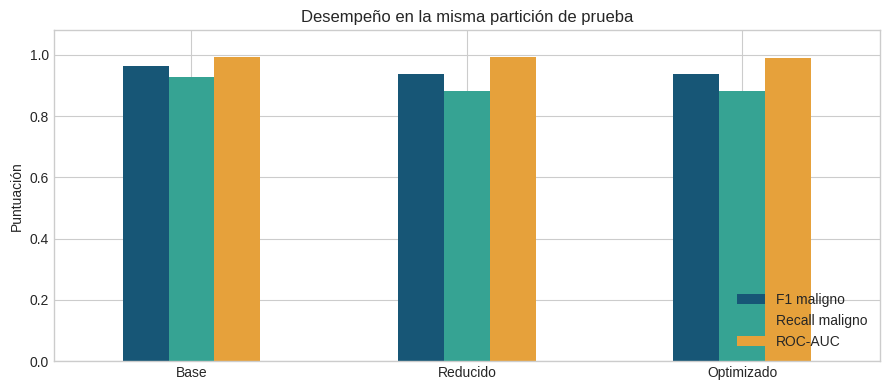

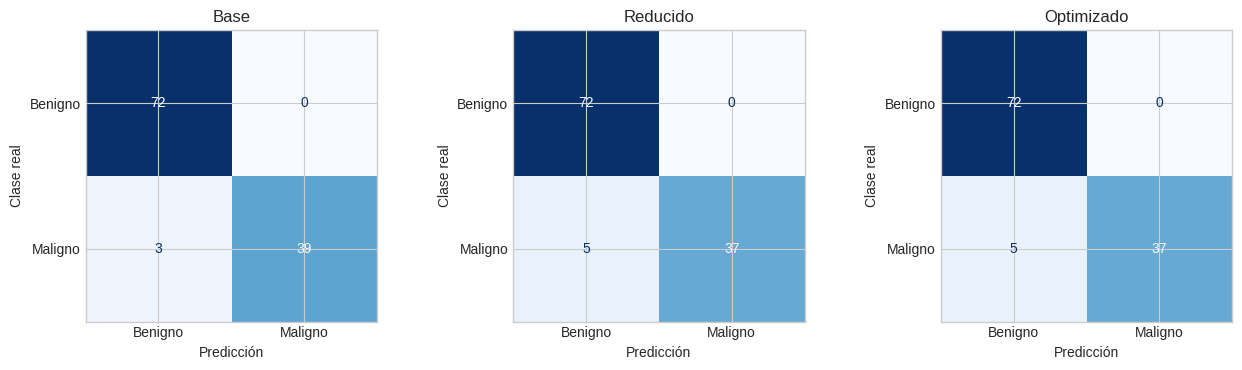

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 4))
results[['F1 maligno', 'Recall maligno', 'ROC-AUC']].plot.bar(ax=ax, color=['#175676', '#36a393', '#e6a13b'])
ax.set(ylim=(0, 1.08), ylabel='Puntuación', xlabel='', title='Desempeño en la misma partición de prueba')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['Benigno', 'Maligno'],
                                            cmap='Blues', colorbar=False, ax=ax)
    ax.set_title(name); ax.set_xlabel('Predicción'); ax.set_ylabel('Clase real')
plt.tight_layout(); plt.show()


## 8. Interpretación del equilibrio entre desempeño y costo
La reducción conserva variables reconocibles y reduce las entradas un 50%, pero el bosque continúa siendo menos interpretable que un árbol pequeño. Menos columnas no garantizan menor tiempo: también influyen profundidad y cantidad de árboles. ANOVA no elimina explícitamente toda la redundancia y no detecta interacciones por sí solo.

La brecha entre F1 de entrenamiento y validación permite identificar señales de sobreajuste. La estabilidad se examina mediante la variación entre folds; el mejor resultado de búsqueda puede ser optimista porque se eligió entre varias alternativas. La prueba independiente ofrece una comprobación adicional, pero una sola partición pequeña no demuestra una ventaja estadística generalizable.

In [8]:
delta_selection = results.loc['Reducido', 'F1 maligno'] - results.loc['Base', 'F1 maligno']
delta_tuning = results.loc['Optimizado', 'F1 maligno'] - results.loc['Reducido', 'F1 maligno']
delta_total = results.loc['Optimizado', 'F1 maligno'] - results.loc['Base', 'F1 maligno']
print(f'Efecto de selección en prueba: {delta_selection:+.4f} F1 ({delta_selection*100:+.2f} puntos porcentuales).')
if abs(delta_selection) <= 0.01:
    print('La reducción conservó un F1 semejante bajo la tolerancia práctica de 0.01, con la mitad de variables.')
elif delta_selection > 0:
    print('La reducción mejoró el F1 observado y conservó la mitad de las variables.')
else:
    print('La reducción perdió desempeño por encima de la tolerancia práctica: pudo descartar información útil.')
print(f'Efecto del ajuste respecto al reducido: {delta_tuning:+.4f} F1.')
for name in cv_table.index:
    gap = cv_table.loc[name, 'F1 entrenamiento CV'] - cv_table.loc[name, 'F1 CV']
    print(f"{name}: F1 CV = {cv_table.loc[name, 'F1 CV']:.4f} ± {cv_table.loc[name, 'DE F1 CV']:.4f}; brecha train–CV = {gap:.4f}.")
print('± corresponde a desviación estándar entre los cinco folds, no a un intervalo de confianza.')


Efecto de selección en prueba: -0.0263 F1 (-2.63 puntos porcentuales).
La reducción perdió desempeño por encima de la tolerancia práctica: pudo descartar información útil.
Efecto del ajuste respecto al reducido: +0.0000 F1.
Base: F1 CV = 0.9519 ± 0.0232; brecha train–CV = 0.0481.
Reducido: F1 CV = 0.9311 ± 0.0316; brecha train–CV = 0.0689.
Optimizado: F1 CV = 0.9257 ± 0.0243; brecha train–CV = 0.0499.
± corresponde a desviación estándar entre los cinco folds, no a un intervalo de confianza.


## 9. Conclusión
La siguiente conclusión se calcula a partir de los resultados de esta ejecución, sin asumir que optimizar necesariamente mejora la prueba.

In [9]:
largest = 'la selección de variables' if abs(delta_selection) >= abs(delta_tuning) else 'el ajuste de hiperparámetros'
print(f'La modificación con mayor efecto absoluto sobre F1 de prueba fue {largest}.')
print(f"F1 base: {results.loc['Base', 'F1 maligno']:.4f}; F1 optimizado: {results.loc['Optimizado', 'F1 maligno']:.4f}.")
if delta_total > 0:
    print(f'El optimizado superó numéricamente al base en esta prueba por {delta_total:.4f} F1; esto no demuestra superioridad generalizable.')
elif delta_total < 0:
    print(f'El optimizado no superó al base: perdió {-delta_total:.4f} F1 en prueba, aunque fue elegido por validación cruzada.')
else:
    print('El optimizado igualó al base en F1 de prueba; no hubo una mejora de esta métrica.')
print(f'La búsqueda costó {search_seconds:.2f} s adicionales. Se pasó de 30 a 15 variables.')
print(f"Ajuste base: {results.loc['Base', 'Tiempo entrenamiento (s)']:.3f} s; optimizado: {results.loc['Optimizado', 'Tiempo entrenamiento (s)']:.3f} s.")
if delta_total <= 0.01:
    print('La evidencia de prueba no muestra una ganancia de F1 superior a la tolerancia práctica que justifique por sí sola el costo de búsqueda.')
else:
    print('La ganancia observada supera la tolerancia práctica, pero habría que confirmar su estabilidad antes de justificar el costo adicional.')
print(f'Recomendaría provisionalmente el modelo {recommended}, conforme a la regla definida en entrenamiento: F1 cercano al mejor CV y menor número de variables/árboles.')
print('Parámetros recomendados:', {p: models[recommended].named_steps['rf'].get_params()[p] for p in ['n_estimators', 'max_depth', 'min_samples_split', 'max_features']})
print('No se cambia esta recomendación utilizando la prueba como otra ronda de ajuste.')
print('Limitación: dataset pequeño, una partición de prueba y solo 12 de 144 combinaciones exploradas; los tiempos se midieron una sola vez.')
print('Evaluación posterior: validación cruzada anidada y repetida para estimar el rendimiento de todo el procedimiento, incluyendo selección y búsqueda; después, validar en datos externos.')


La modificación con mayor efecto absoluto sobre F1 de prueba fue la selección de variables.
F1 base: 0.9630; F1 optimizado: 0.9367.
El optimizado no superó al base: perdió 0.0263 F1 en prueba, aunque fue elegido por validación cruzada.
La búsqueda costó 52.21 s adicionales. Se pasó de 30 a 15 variables.
Ajuste base: 0.399 s; optimizado: 0.325 s.
La evidencia de prueba no muestra una ganancia de F1 superior a la tolerancia práctica que justifique por sí sola el costo de búsqueda.
Recomendaría provisionalmente el modelo Base, conforme a la regla definida en entrenamiento: F1 cercano al mejor CV y menor número de variables/árboles.
Parámetros recomendados: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'sqrt'}
No se cambia esta recomendación utilizando la prueba como otra ronda de ajuste.
Limitación: dataset pequeño, una partición de prueba y solo 12 de 144 combinaciones exploradas; los tiempos se midieron una sola vez.
Evaluación posterior: validación cr